# Business Understanding

## Project Domain

Domain: Teknologi dan Kecerdasan Buatan

Sub-Domain: Klasifikasi Gender Suara

Sistem klasifikasi gender suara ini bertujuan untuk mengidentifikasi jenis kelamin seseorang berdasarkan fitur suara mereka. Penggunaan utama bisa termasuk aplikasi dalam sistem keamanan, autentikasi suara, dan analisis data audio.

## Problem Statements

Masalah yang Dihadapi:
1. Kesulitan dalam Identifikasi Gender Secara Manual:

  *  Pengguna atau sistem perlu mengidentifikasi gender secara akurat dalam waktu singkat dari data audio.

  *   Tanpa sistem otomatis, identifikasi gender dapat memakan waktu dan tidak akurat.

2. Penggunaan di Berbagai Aplikasi:

  * Banyak aplikasi yang membutuhkan deteksi otomatis gender suara untuk autentikasi atau analisis data berbasis suara.

3. Kesulitan dalam Otomatisasi Proses:

  * Tanpa sistem otomatis berbasis AI, proses ini lebih lambat dan lebih mahal jika menggunakan tenaga manusia.


## Goals

1. **Tujuan Model:**

  *  Mengembangkan Artificial Neural Network (ANN) yang dapat mengklasifikasikan jenis kelamin berdasarkan fitur suara (meanfreq, sd, median, dll.).

  *  Model dapat menerima input fitur suara dan memberikan prediksi gender (male/female).

  * Membangun model AI untuk mengklasifikasikan gender suara dengan akurasi tinggi (>90%).

  * Membuat antarmuka pengguna berbasis web yang memungkinkan input suara dan menerima hasil prediksi dalam waktu instan.

  * Mengoptimalkan model agar dapat digunakan pada perangkat dengan sumber daya terbatas.

2. **Aplikasi Web:**

  * Membangun antarmuka berbasis Streamlit yang memungkinkan pengguna untuk mengunggah file suara atau memasukkan fitur suara secara manual dan mendapatkan hasil prediksi gender secara real-time.

3. **Optimasi:**

  * Mengonversi model ke TensorFlow Lite agar dapat digunakan di perangkat dengan sumber daya terbatas (misalnya aplikasi mobile atau IoT).

## Solustion Statements

**Machine Learning Model**

  *   **Model**: Menggunakan Artificial Neural Network (ANN) untuk klasifikasi gender berdasarkan dataset suara.

  *  **Fitur**: Dataset akan menggunakan fitur-fitur seperti meanfreq, sd, median, skew, kurt, dll.

  * **Output**: Dua kelas, Male atau Female, yang dapat diprediksi oleh model.

**Aplikasi Web (Streamlit)**
  * Membuat antarmuka pengguna yang memungkinkan input suara (fitur yang sudah diekstraksi) atau input langsung dari pengguna.
   
  * Hasil prediksi gender ditampilkan secara instan untuk memberikan pengalaman pengguna yang cepat dan efisien.

**Optimasi dengan TensorFlow Lite**

  * Model yang telah dilatih di TensorFlow akan dioptimalkan ke dalam format TensorFlow Lite (TFLite) untuk memastikan dapat dijalankan pada perangkat mobile atau perangkat dengan sumber daya terbatas.

# Data Understanding

## Import Data dari Kaggle

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"maryamnurazizah","key":"946d53023dc0a1b930b12502d3e578ff"}'}

In [40]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [8]:
!kaggle datasets download -d primaryobjects/voicegender

Dataset URL: https://www.kaggle.com/datasets/primaryobjects/voicegender
License(s): CC-BY-NC-SA-4.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [9]:
!mkdir voicegender
!unzip voicegender -d voicegender
!ls voicegender

Archive:  voicegender.zip
  inflating: voicegender/voice.csv   
voice.csv


## Import Library yang dibutuhkan

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [11]:
df = pd.read_csv('voicegender/voice.csv')

In [45]:
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

<ipython-input-14-0e39c1b44810>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='pastel')


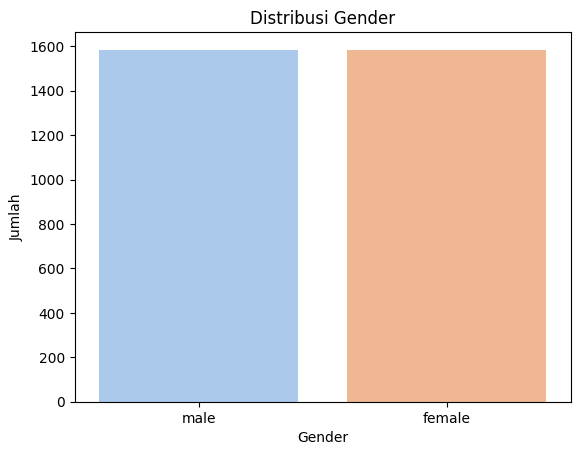

In [ ]:
#1. Distribusi gender
sns.countplot(data=df, x='label', palette='pastel')
plt.title('Distribusi Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.show()


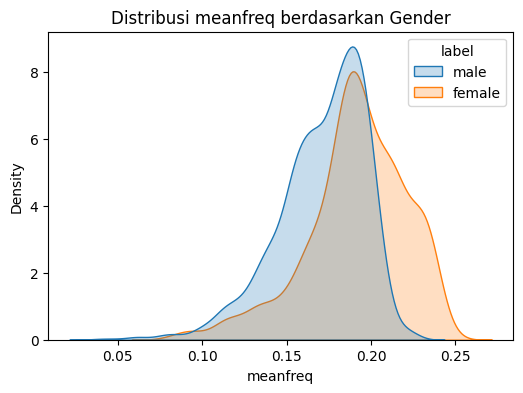

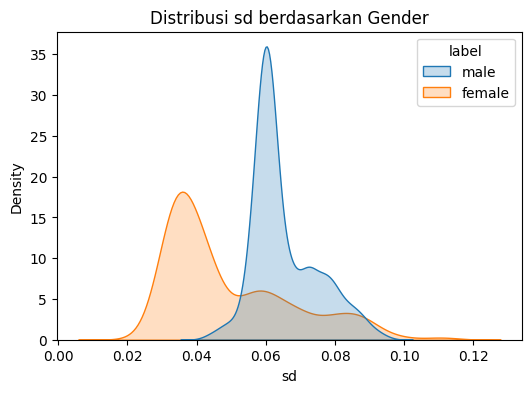

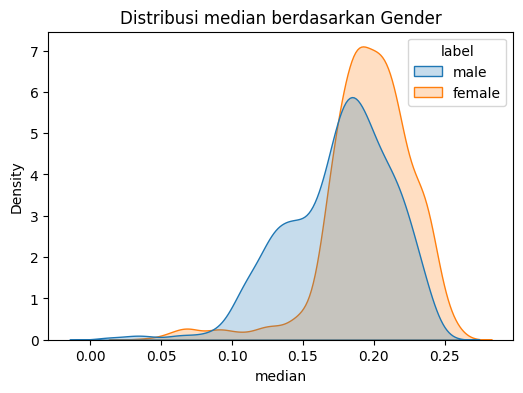

In [ ]:
#2. Distribusi meanfreq, sd, dan median berdasarkan gender
features = ['meanfreq', 'sd', 'median']
for feature in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=feature, hue='label', fill=True)
    plt.title(f'Distribusi {feature} berdasarkan Gender')
    plt.show()



<ipython-input-16-1eba8260fb65>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='meanfreq', palette='Set2')


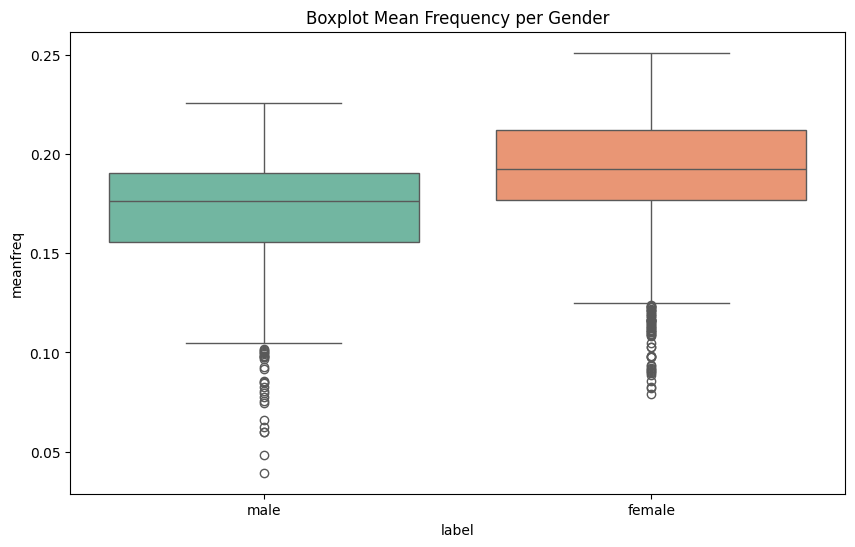

In [ ]:
#3. Mean Frequency Per Gender
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='meanfreq', palette='Set2')
plt.title('Boxplot Mean Frequency per Gender')
plt.show()


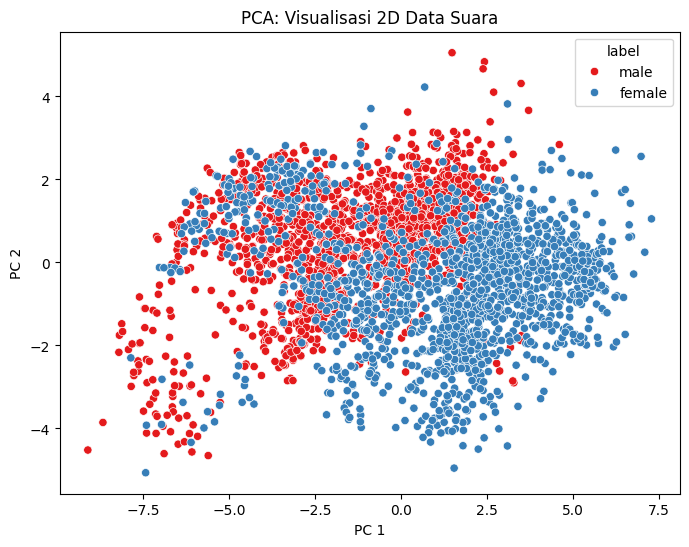

In [ ]:
#4. Visualisai 2D data Suara
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Encode label dan scale fitur
X = df.drop('label', axis=1)
y = df['label']
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title('PCA: Visualisasi 2D Data Suara')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()


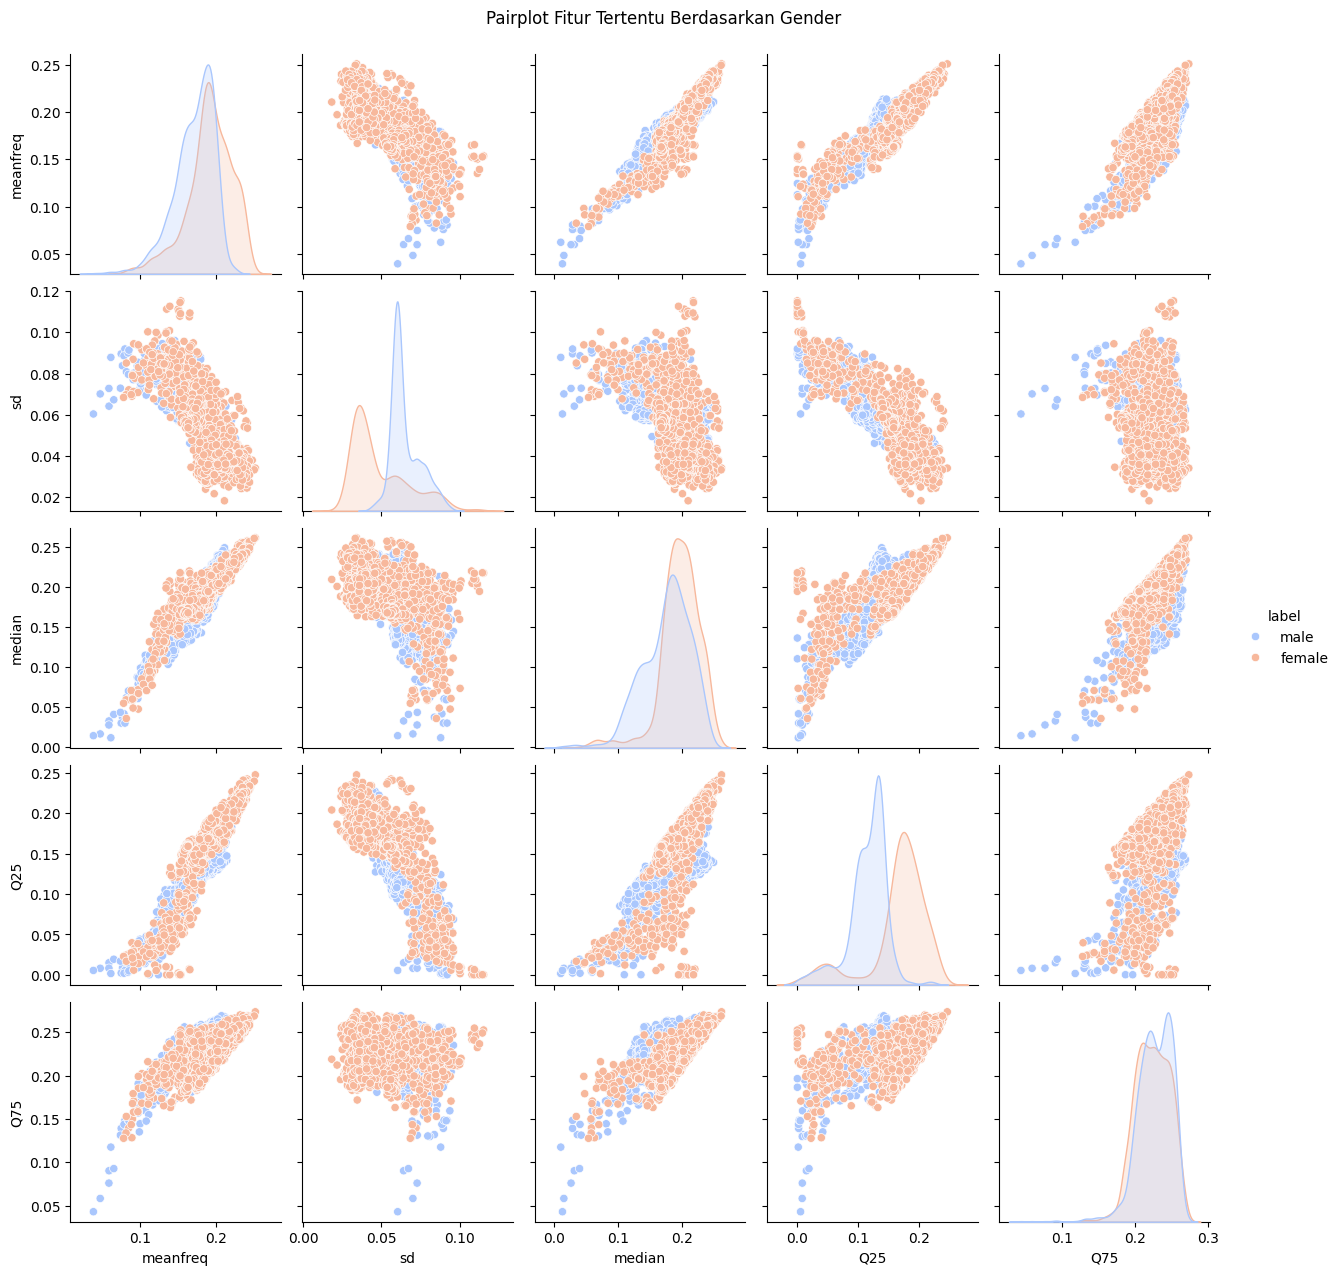

In [ ]:
#5. Pairplot fitur tertentu berdasarkan geder
subset = df[['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'label']]
sns.pairplot(subset, hue='label', palette='coolwarm')
plt.suptitle('Pairplot Fitur Tertentu Berdasarkan Gender', y=1.02)
plt.show()


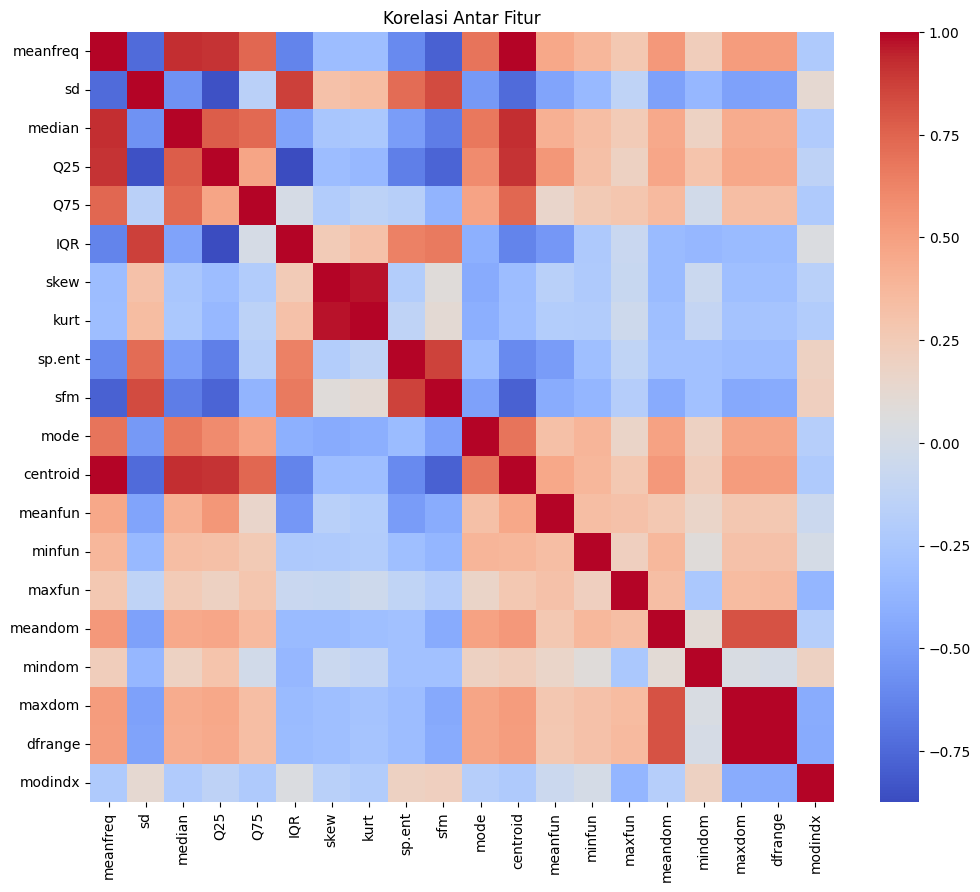

In [ ]:
#6. Korelasi antar fitur
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap='coolwarm') # Select only numeric columns for correlation calculation
plt.title('Korelasi Antar Fitur')
plt.show()

# Data Preparation

In [20]:
# pisahkan fitur dan target
X = df.drop(columns=["label"])
y = df["label"]

In [21]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [24]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [25]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,090 (51.13 KB)

 Trainable params: 13,090 (51.13 KB)

 Non-trainable params: 0 (0.00 B)

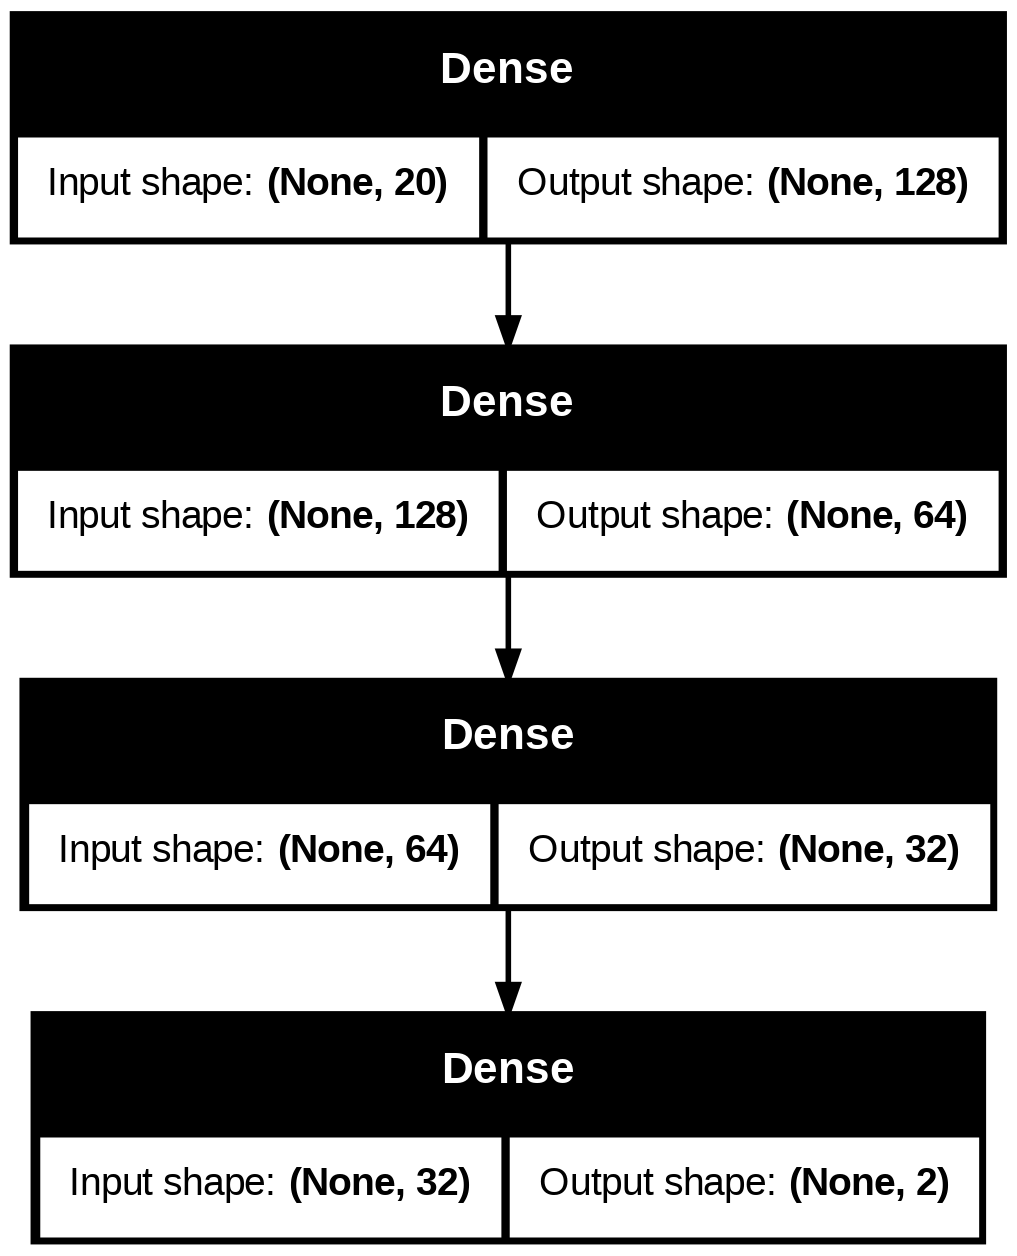

In [27]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [28]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8051 - loss: 0.4714 - val_accuracy: 0.9606 - val_loss: 0.1412
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9598 - loss: 0.1266 - val_accuracy: 0.9732 - val_loss: 0.0946
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9738 - loss: 0.0975 - val_accuracy: 0.9795 - val_loss: 0.0718
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9695 - loss: 0.0954 - val_accuracy: 0.9700 - val_loss: 0.0976
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9777 - loss: 0.0775 - val_accuracy: 0.9653 - val_loss: 0.0975
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0896 - val_accuracy: 0.9606 - val_loss: 0.1096
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0686 - val_accuracy: 0.9811 - val_loss: 0.0656
Epoch 8/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9675 - loss: 0.0957 - val_accuracy: 0.

# Evaluation

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9795 - loss: 0.0908 
Akurasi Model: 0.9811
Loss Model: 0.0691


In [30]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

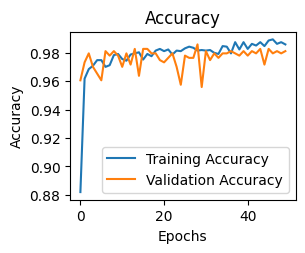

In [31]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

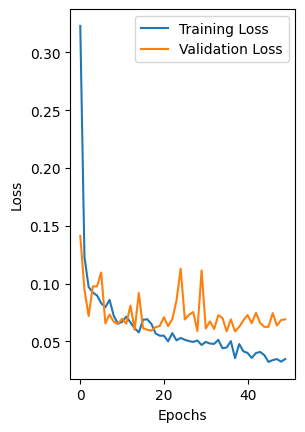

In [32]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


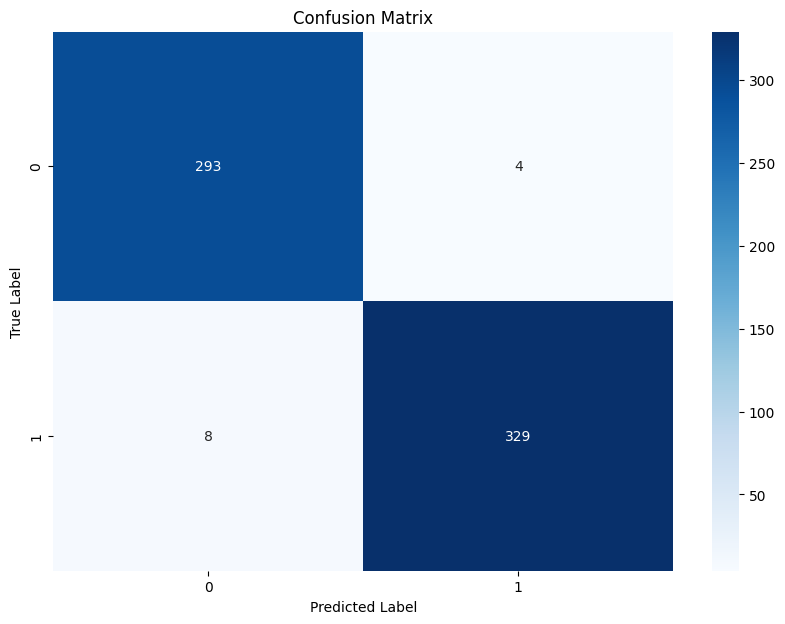

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       297
           1       0.99      0.98      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



In [33]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [50]:
sample_input = np.array([[
    0.158107989456496,0.0827815915759607,0.191191454396056,0.0623500410846343,
    0.22455217748562,0.162202136400986,2.80134396306528,19.9296167053104,
    0.952160964900451,0.679223312622536,0.0499260476581758,0.158107989456496,
    0.185041734793057,0.023021582733813,0.275862068965517,0.272964015151515,
    0.046875,0.7421875,0.6953125,0.339887640449438
]])

feature_names = [
    "meanfreq", "sd", "median", "Q25", "Q75", "IQR", "skew", "kurt",
    "sp.ent", "sfm", "mode", "centroid", "meanfun", "minfun", "maxfun",
    "meandom", "mindom", "maxdom", "dfrange", "modindx"
]

sample_input_df = pd.DataFrame(sample_input, columns=feature_names)


In [51]:
sample_input_scaled = scaler.transform(sample_input_df)

In [55]:
scaler = joblib.load("scaler.pkl")
model = tf.keras.models.load_model("voice_gender_model.h5")
label_encoder = joblib.load("label_encoder.pkl")

# Prediksi
prediction = model.predict(sample_input_scaled)
predicted_class = np.argmax(prediction, axis=1)[0]
mapped_label = label_encoder.inverse_transform([predicted_class])[0]

print("Prediksi Suara:", mapped_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Prediksi Suara: female


## Save Model

In [41]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('voicegender.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpyrlf_cu3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135266637079440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637078288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637081744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637082704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637078672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637082896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637079056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135266637080592: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [42]:
# Simpan model
model.save("voice_gender_model.h5")

In [43]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']